                                          Random forest classifier -iris Flower data set

In [ ]:
Task: implement Random forest classifier ml model on lris data set and predict target classes


In [ ]:
1.import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
2. load the iris data from sklearn and store it in data freme

In [4]:
from sklearn.datasets import load_iris
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [ ]:
3.data preprocessing and EDA

In [5]:
df.ndim

2

In [6]:
df.shape

(150, 5)

In [7]:
df.size

750

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [9]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [11]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

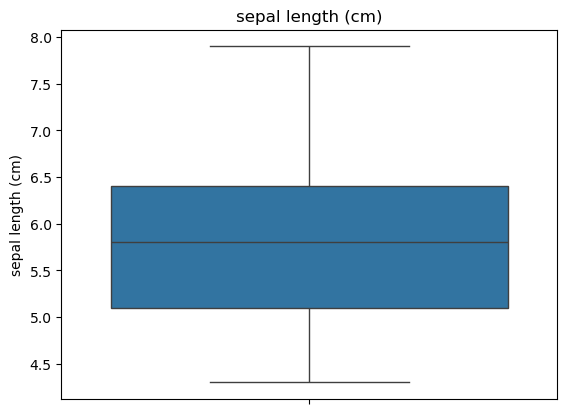

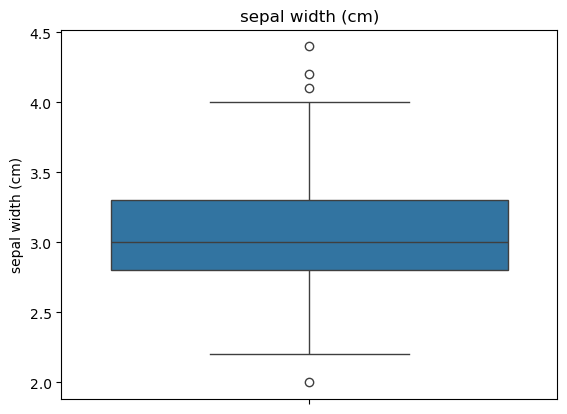

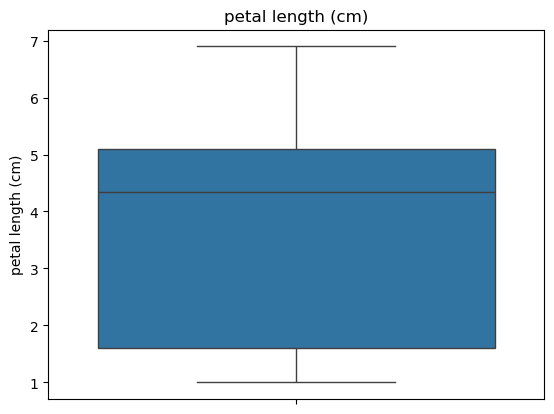

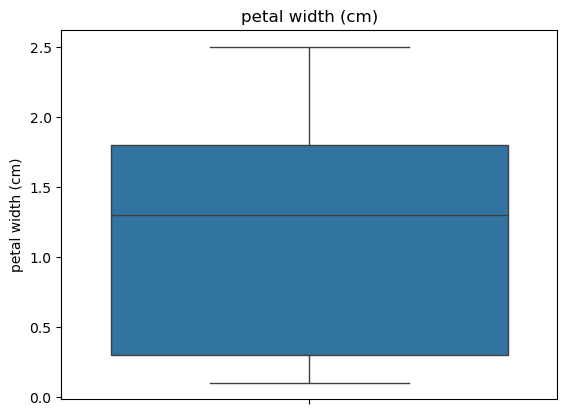

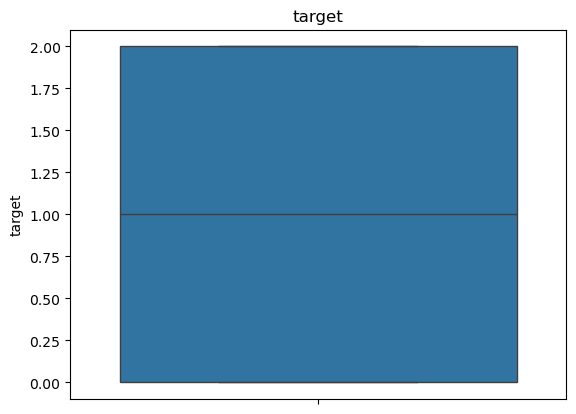

In [12]:
# check the outliers
for i in df.columns:
    sns.boxplot(df[i])
    plt.title(i)
    plt.show()

In [6]:
for i in df.columns:
    if(i!='target'):
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        lb=q1-1.5*iqr
        ub=q3+1.5*iqr
        df=df[(df[i]>=lb) & (df[i]<=ub)]

In [7]:
# split the x and y
x=df.drop('target',axis=1)
y=df['target']

In [8]:
#standardize data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [11]:
#Divide the data into  test and train 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,train_size=0.75,random_state=42)
print(x_train.shape)
print(x_test.shape)

(109, 4)
(37, 4)


In [ ]:
#4 Build the model

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import*

In [14]:
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
5.predict model output

In [15]:
y_pred=rfc.predict(x_test)

In [ ]:
6. show the actual ,predict output

In [21]:
res=pd.DataFrame({'actual':y_test,'predicted':y_pred,
                  'error':y_test-y_pred,
                  'error_square':(y_test-y_pred)**2})
                 
res.head(10)

,actual,predicted,error,error_square
48,0,0,0,0
101,2,2,0,0
28,0,0,0,0
20,0,0,0,0
45,0,0,0,0
124,2,2,0,0
30,0,0,0,0
84,1,1,0,0
70,1,2,-1,1
19,0,0,0,0


In [22]:
# display the numbers of error samples
res['error_square'].value_counts()

error_square
0    35
1     2
Name: count, dtype: int64

In [ ]:
7.Evaluate model performance

In [23]:
# 8.1 Display the confusion matrix
cm=confusion_matrix(y_test,y_pred)
print('Confusion matrix:\n',cm)

Confusion matrix:
 [[16  0  0]
 [ 0  7  1]
 [ 0  1 12]]


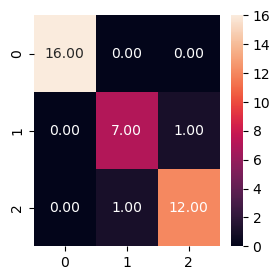

In [24]:
# 8.2 display the heat map
plt.figure(figsize=(3,3))
sns.heatmap(cm,annot=True,fmt='0.2f')
plt.show()

In [26]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)
   


0.9459459459459459


In [27]:
#8.7 Classification Report
print('Classification Report:\n',classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.88      0.88      0.88         8
           2       0.92      0.92      0.92        13

    accuracy                           0.95        37
   macro avg       0.93      0.93      0.93        37
weighted avg       0.95      0.95      0.95        37



In [38]:
new_flower = [[1,2,3,4]]

prediction = rfc.predict(new_flower_scaled)

print("Prediction:")

if prediction[0] == 0:
    print("Setosa")
elif prediction[0] == 1:
    print("Versicolor")
else:
    print("Virginica")
   


Prediction:
Setosa
